In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

from helper.quantumScarsCheck import *
from helper.quantumScarFunctions import *
from helper.quantumScarsPlotting import *

In [12]:
N = 10
H0, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, fixed_seed=False, ohms=1.0)
H1, _ = get_scar_H1(N, basisList, ds_dis=0.0, N_dis=None, fixed_seed=False, indv_qubit=False)

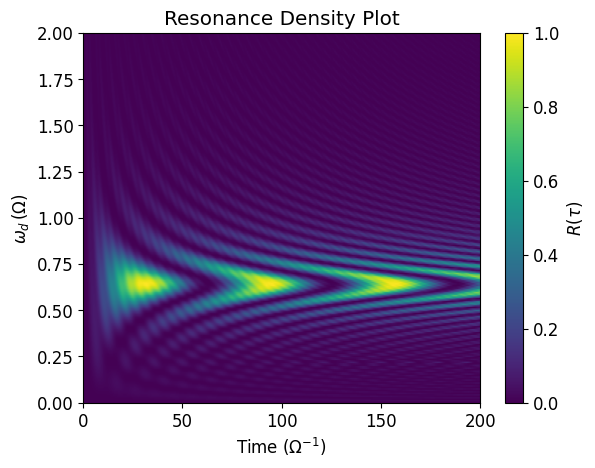

In [14]:
# plot the expectation values of the sparse matrix throughout time with different omega
band = eigenvalues[-1] - eigenvalues[0]

wlist = np.linspace(0, 2, 250)
tlist = np.linspace(0, 200, 400)
expectationVals = []
tempExpectation = []

for omega in wlist:

    args = {"A": 0.1, "omega": omega}
    H = qt.QobjEvo([H0, [H1, coeff]], args=args) # create H using QobjEvo
    psi_t = qt.sesolve(H, eigenstates[0], tlist) # evolve the H through time
    tempExpectation = []

    for states in psi_t.states:

        val = states.dag() * H0 * states
        tempExpectation.append(val.real)

    expectationVals.append(tempExpectation)

plt.imshow((np.array(expectationVals) - eigenvalues[0]) / band,
           extent=[tlist.min(), tlist.max(), wlist.min(), wlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label=r"$R(\tau)$")

plt.xlabel(r"Time ($\Omega^{-1}$)")
plt.ylabel(r"$\omega_d \, (\Omega)$")
plt.title("Resonance Density Plot")
plt.savefig("figures/resonance.pdf")
plt.show()

In [11]:
thearray = (np.array(expectationVals) - eigenvalues[0]) / band
highest = np.max((np.array(expectationVals) - eigenvalues[0]) / band)
ind = np.unravel_index(np.argmax(thearray, axis=None), thearray.shape)

print(wlist[ind[0]])
print(highest)
print(ind)

0.6365091993031289
0.9734403158859546
(np.int64(166), np.int64(627))


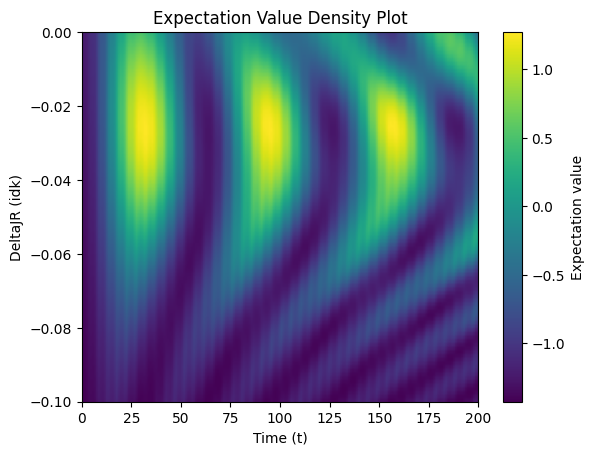

In [ ]:
# plot the expectation values of the sparse matrix throughout time with different JR
jrList = np.linspace(-0.1, 0, 100)
tlist = np.linspace(0, 200, 200)
expectationVals = []
tempExpectation = []

for jr in jrList:

    jrH0 = qt.Qobj((ohms / 2 * sparseBareHamiltonian) + (jr * ohms * sparseFactoredHamiltonian))
    args = {"A": 0.1, "omega": 0.6366896896896898}
    H = qt.QobjEvo([jrH0, [H1, coeff]], args=args) # create H using QobjEvo
    psi_t = qt.sesolve(H, eigenstates[0], tlist) # evolve the ground state through time
    tempExpectation = []

    for states in psi_t.states:

        val = states.dag() * jrH0 * states
        tempExpectation.append(val.real)

    expectationVals.append(tempExpectation)

plt.imshow(expectationVals,
           extent=[tlist.min(), tlist.max(), jrList.min(), jrList.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis')
plt.colorbar(label="Expectation value")

plt.xlabel("Time (t)")
plt.ylabel("DeltaJR (idk)")
plt.title("Expectation Value Density Plot")
# plt.savefig("plots//expectDensityPlot.pdf")
plt.show()

[0, 1, 6, 18, 36, 63, 86, 104, 116, 121, 122]


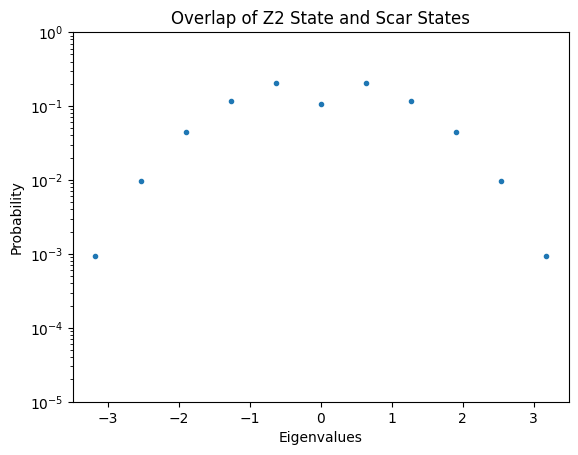

In [ ]:
# find scar indices using overlaps
sections = np.linspace(eigenvalues[0] - 0.5, eigenvalues[-1] + 0.5, N+2)
scarIndices = []

for i in range(len(sections) - 1):

    eigenSection = []

    for k in range(len(eigenvalues)):
        if (eigenvalues[k] > sections[i]) and (eigenvalues[k] < sections[i+1]):
            eigenSection.append(k)

    highestOverlap = np.abs(psi0.dag() * eigenstates[eigenSection[0]]) ** 2
    highestOverlapIndex = eigenSection[0]

    if len(eigenSection) == 1:
        scarIndices.append(eigenSection[0])
        continue
        
    for m in range(1, len(eigenSection)):
        if np.abs(psi0.dag() * eigenstates[eigenSection[m]]) ** 2 > highestOverlap:
            highestOverlap = np.abs(psi0.dag() * eigenstates[eigenSection[m]]) ** 2
            highestOverlapIndex = eigenSection[m]
    
    scarIndices.append(highestOverlapIndex)

print(scarIndices)

amplitudes = []
eigenvalueIndices = []

for i in scarIndices:
    amplitudes.append(psi0.dag() * eigenstates[i])
    eigenvalueIndices.append(eigenvalues[i])

plt.figure()
plt.plot(eigenvalueIndices, np.abs(amplitudes) ** 2, ".")
plt.yscale("log")
plt.ylim(10**-5, 1)
plt.xlabel("Eigenvalues")
plt.ylabel("Probability")
plt.title("Overlap of Z2 State and Scar States")
plt.show()
    

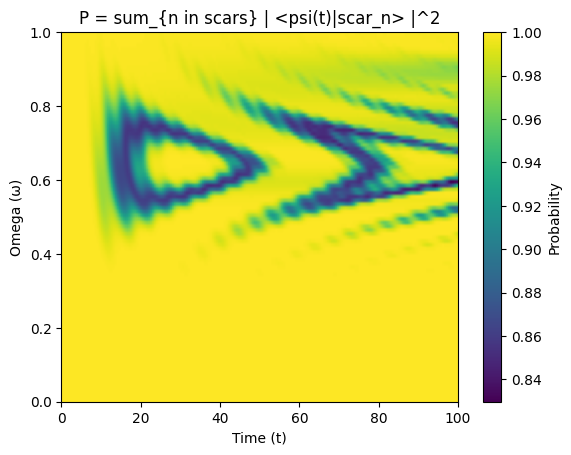

In [ ]:
wlist = np.linspace(0.0, 1.0, 100)
tlist = np.linspace(0, 100, 200)
scarStates = [eigenstates[i] for i in scarIndices]
scar_psit_probs = []
tempProbabilities = []

for omega in wlist:

    args = {"A": 0.1, "omega": omega}
    H = qt.QobjEvo([H0, [H1, coeff]], args=args) # create H using QobjEvo
    psi_t = qt.sesolve(H, eigenstates[0], tlist) # evolve the H through time
    tempProbabilities = []

    for states in psi_t.states:
        prob = 0.0

        for scars in scarStates:
            prob += np.abs(states.dag() * scars) ** 2

        tempProbabilities.append(prob)

    scar_psit_probs.append(tempProbabilities)

plt.imshow(scar_psit_probs,
           extent=[tlist.min(), tlist.max(), wlist.min(), wlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis')
plt.colorbar(label="Probability")

plt.xlabel("Time (t)")
plt.ylabel("Omega (ω)")
plt.title("P = sum_{n in scars} | <psi(t)|scar_n> |^2")
plt.show()

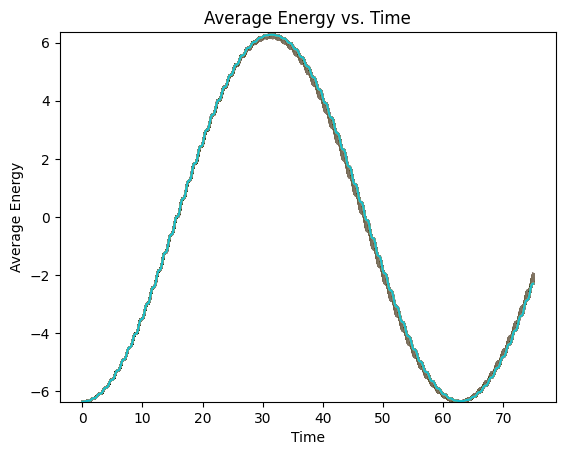

In [21]:
ohms = 5.0

tlist_limited = np.linspace(0, 75, 500)
wlist_limited = np.linspace(0.635, 0.637, 1000)
expectationVals_limited = {}
tempExpectation_limited = []

H0, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, ohms=ohms)

for omega in wlist_limited:

    args = {"A": 0.1, "omega": omega*ohms}
    H = qt.QobjEvo([H0, [H1, coeff]], args=args) # create H using QobjEvo
    psi_t = qt.sesolve(H, eigenstates[0], tlist_limited) # evolve the H through time
    tempExpectation_limited = []

    for states in psi_t.states:

        val = states.dag() * H0 * states
        tempExpectation_limited.append(val.real)
    
    expectationVals_limited[omega] = tempExpectation_limited

for omega in wlist_limited:
    plt.plot(tlist_limited, expectationVals_limited[omega], label=f"$\\omega = {omega:.2f}$")

plt.xlabel("Time")
plt.ylabel("Average Energy")
plt.title("Average Energy vs. Time")
plt.ylim(eigenvalues[0], eigenvalues[-1])
# plt.legend()
plt.show()

In [ ]:
# find wc - omega with the highest average energy peak
wc_potential = {}

for omega in wlist_limited:
    wc_potential[omega] = max(expectationVals_limited[omega])

best_omega = max(wc_potential, key=wc_potential.get)
wc_omega_pair = {float(best_omega): wc_potential[best_omega]}

print(wc_omega_pair)
# 0.6366896896896898
print(eigenvalues[0], eigenvalues[-1])

{0.6366896896896898: 6.2777629314576275}
-6.3644009930236125 6.364400993023616


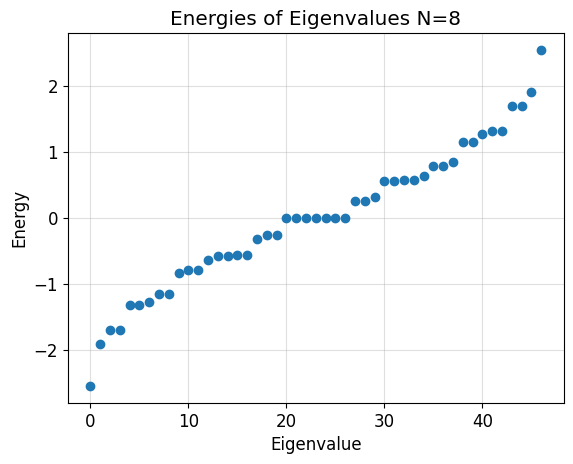

In [7]:
plotEigEnergies(H0, N)

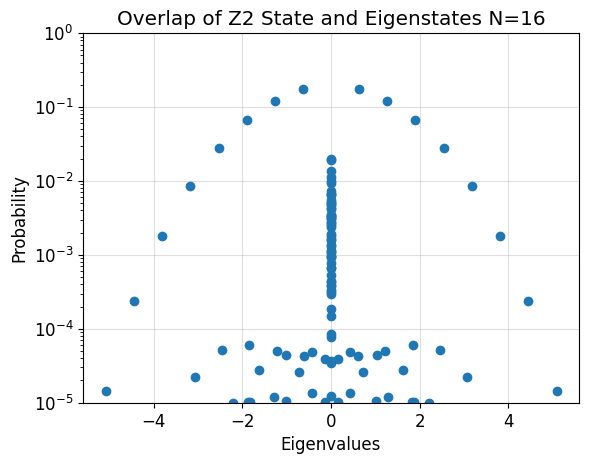

In [4]:
plotAmpEigenstatesZ2Log(H0, psi0, N)

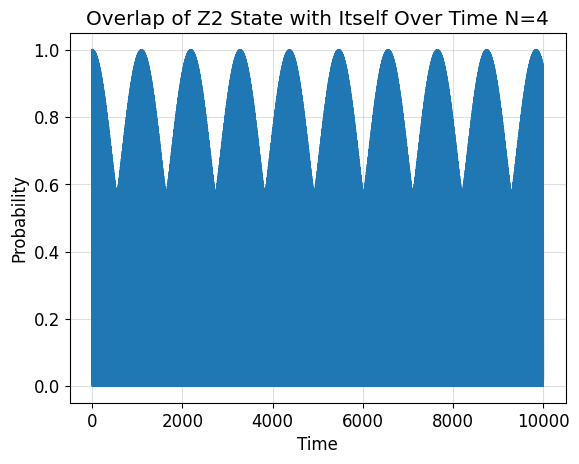

In [29]:
plotProbZ2Time(H0, N, psi0, t=10000)